In [1]:
!nvidia-smi

Fri Jun  5 22:24:38 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   34C    P0             48W /  400W |       0MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [2]:
!git clone https://github.com/ZuomingWang/matbench-tabpfn.git
%cd matbench-tabpfn

Cloning into 'matbench-tabpfn'...
remote: Enumerating objects: 82, done.
remote: Counting objects: 100% (82/82), done.
remote: Compressing objects: 100% (74/74), done.
remote: Total 82 (delta 8), reused 79 (delta 6), pack-reused 0 (from 0)
Receiving objects: 100% (82/82), 26.44 MiB | 16.53 MiB/s, done.
Resolving deltas: 100% (8/8), done.
/content/matbench-tabpfn


In [4]:
!pwd
!ls

/content/matbench-tabpfn
archive  docs		  notebooks  ref	       results	src
configs  environment.yml  README.md  requirements.txt  scripts


In [5]:
!pip install -q "numpy<3" "pandas<3" "scikit-learn>=1.3,<2" "scipy>=1.11" matplotlib seaborn joblib tqdm pyyaml "pymatgen>=2023" matminer==0.10.1 tabpfn==8.0.3 shap
!pip install -q --no-deps matbench==0.6

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 7.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 7.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 107.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 727.1/727.1 kB 35.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 76.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 829.1/829.1 kB 72.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 145.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 108.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.1/331.1 kB 39.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 332.3/332.3 kB 39.5 MB/s eta 0:00:00
   ━━

In [6]:
!ls scripts

check_setup.py	run_small_data_diagnostics.py  setup_env.sh


In [7]:
!python scripts/run_small_data_diagnostics.py \
  --models extra_trees \
  --folds 0 \
  --fractions 0.2 1.0 \
  --device cpu

2026-06-05 22:27:00 INFO     Initialized benchmark 'matbench_v0.1' with 1 tasks: 
['matbench_jdft2d']
2026-06-05 22:27:00 INFO     Loading dataset 'matbench_jdft2d'...
Fetching matbench_jdft2d.json.gz from https://ml.materialsproject.org/projects/matbench_jdft2d.json.gz to /usr/local/lib/python3.12/dist-packages/matminer/datasets/matbench_jdft2d.json.gz
Fetching https://ml.materialsproject.org/projects/matbench_jdft2d.json.gz in MB: 0.26828799999999997MB [00:00, 214.26MB/s]
2026-06-05 22:27:00 INFO     Dataset 'matbench_jdft2d loaded.
Building features: matbench_jdft2d | magpie
matbench_jdft2d | magpie | extra_trees | fold 0 | fraction 0.20 | repeat 0
matbench_jdft2d | magpie | extra_trees | fold 0 | fraction 1.00 | repeat 0
Building features: matbench_jdft2d | magpie_structure_all
matbench_jdft2d | magpie_structure_all | extra_trees | fold 0 | fraction 0.20 | repeat 0
matbench_jdft2d | magpie_structure_all | extra_trees | fold 0 | fraction 1.00 | repeat 0
2026-06-05 22:29:35 INFO     

In [8]:
!python scripts/run_small_data_diagnostics.py \
  --models extra_trees tabpfn \
  --fractions 0.1 0.2 0.4 0.6 0.8 1.0 \
  --repeats 1 \
  --device cuda

2026-06-05 22:35:35 INFO     Initialized benchmark 'matbench_v0.1' with 1 tasks: 
['matbench_jdft2d']
2026-06-05 22:35:35 INFO     Loading dataset 'matbench_jdft2d'...
2026-06-05 22:35:35 INFO     Dataset 'matbench_jdft2d loaded.
Building features: matbench_jdft2d | magpie
matbench_jdft2d | magpie | extra_trees | fold 0 | fraction 0.10 | repeat 0
matbench_jdft2d | magpie | tabpfn | fold 0 | fraction 0.10 | repeat 0

TabPFN requires a one-time license acceptance to download model weights for local inference.

No display detected. Open this URL in a browser on another device:

  https://ux.priorlabs.ai/login?hf_repo_id=tabpfn_3

After logging in, accept the license on the Licenses tab,
then copy your API Key from
  https://ux.priorlabs.ai/account

  [c] Copy URL to clipboard    Paste your API key to continue

> tabpfn_sk__WSDaZCLfRRCwdqv7U8k4V0sIPmfJioMmeAvzr8Eghg
License accepted — API key cached for future sessions.

tabpfn-v3-regressor-v3_default.ckpt: 100% 233M/233M [00:02<00:00, 94.

In [9]:
import glob
latest = sorted(glob.glob("results/small_data_diagnostics/*"))[-1]
print(latest)

results/small_data_diagnostics/gpu_20260605_223535_utc


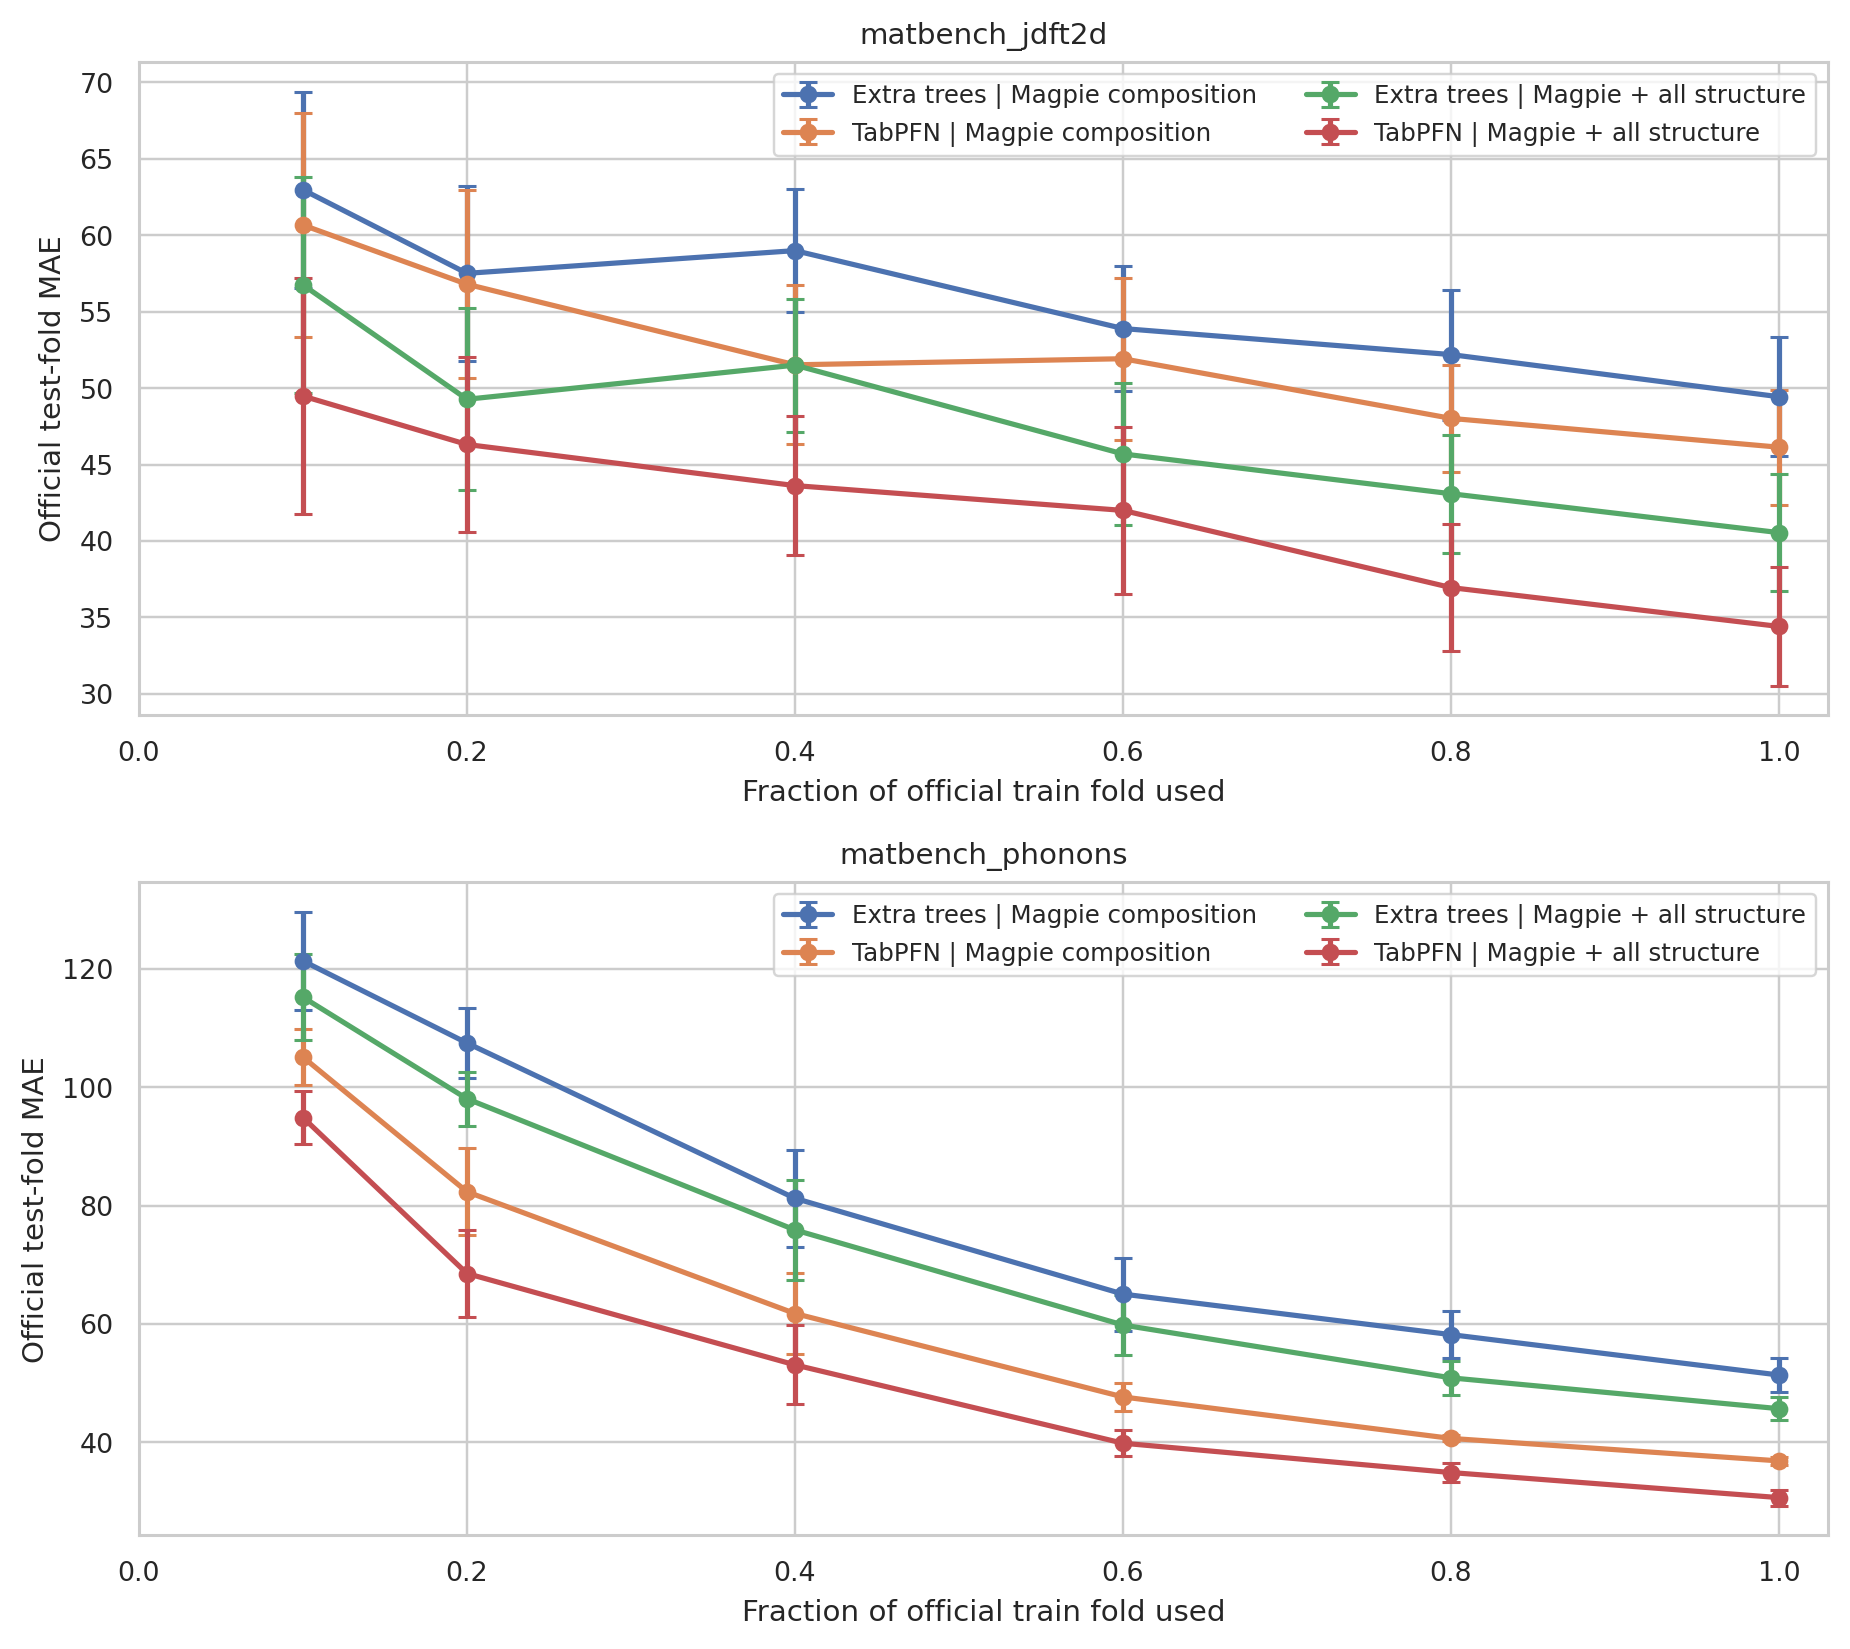

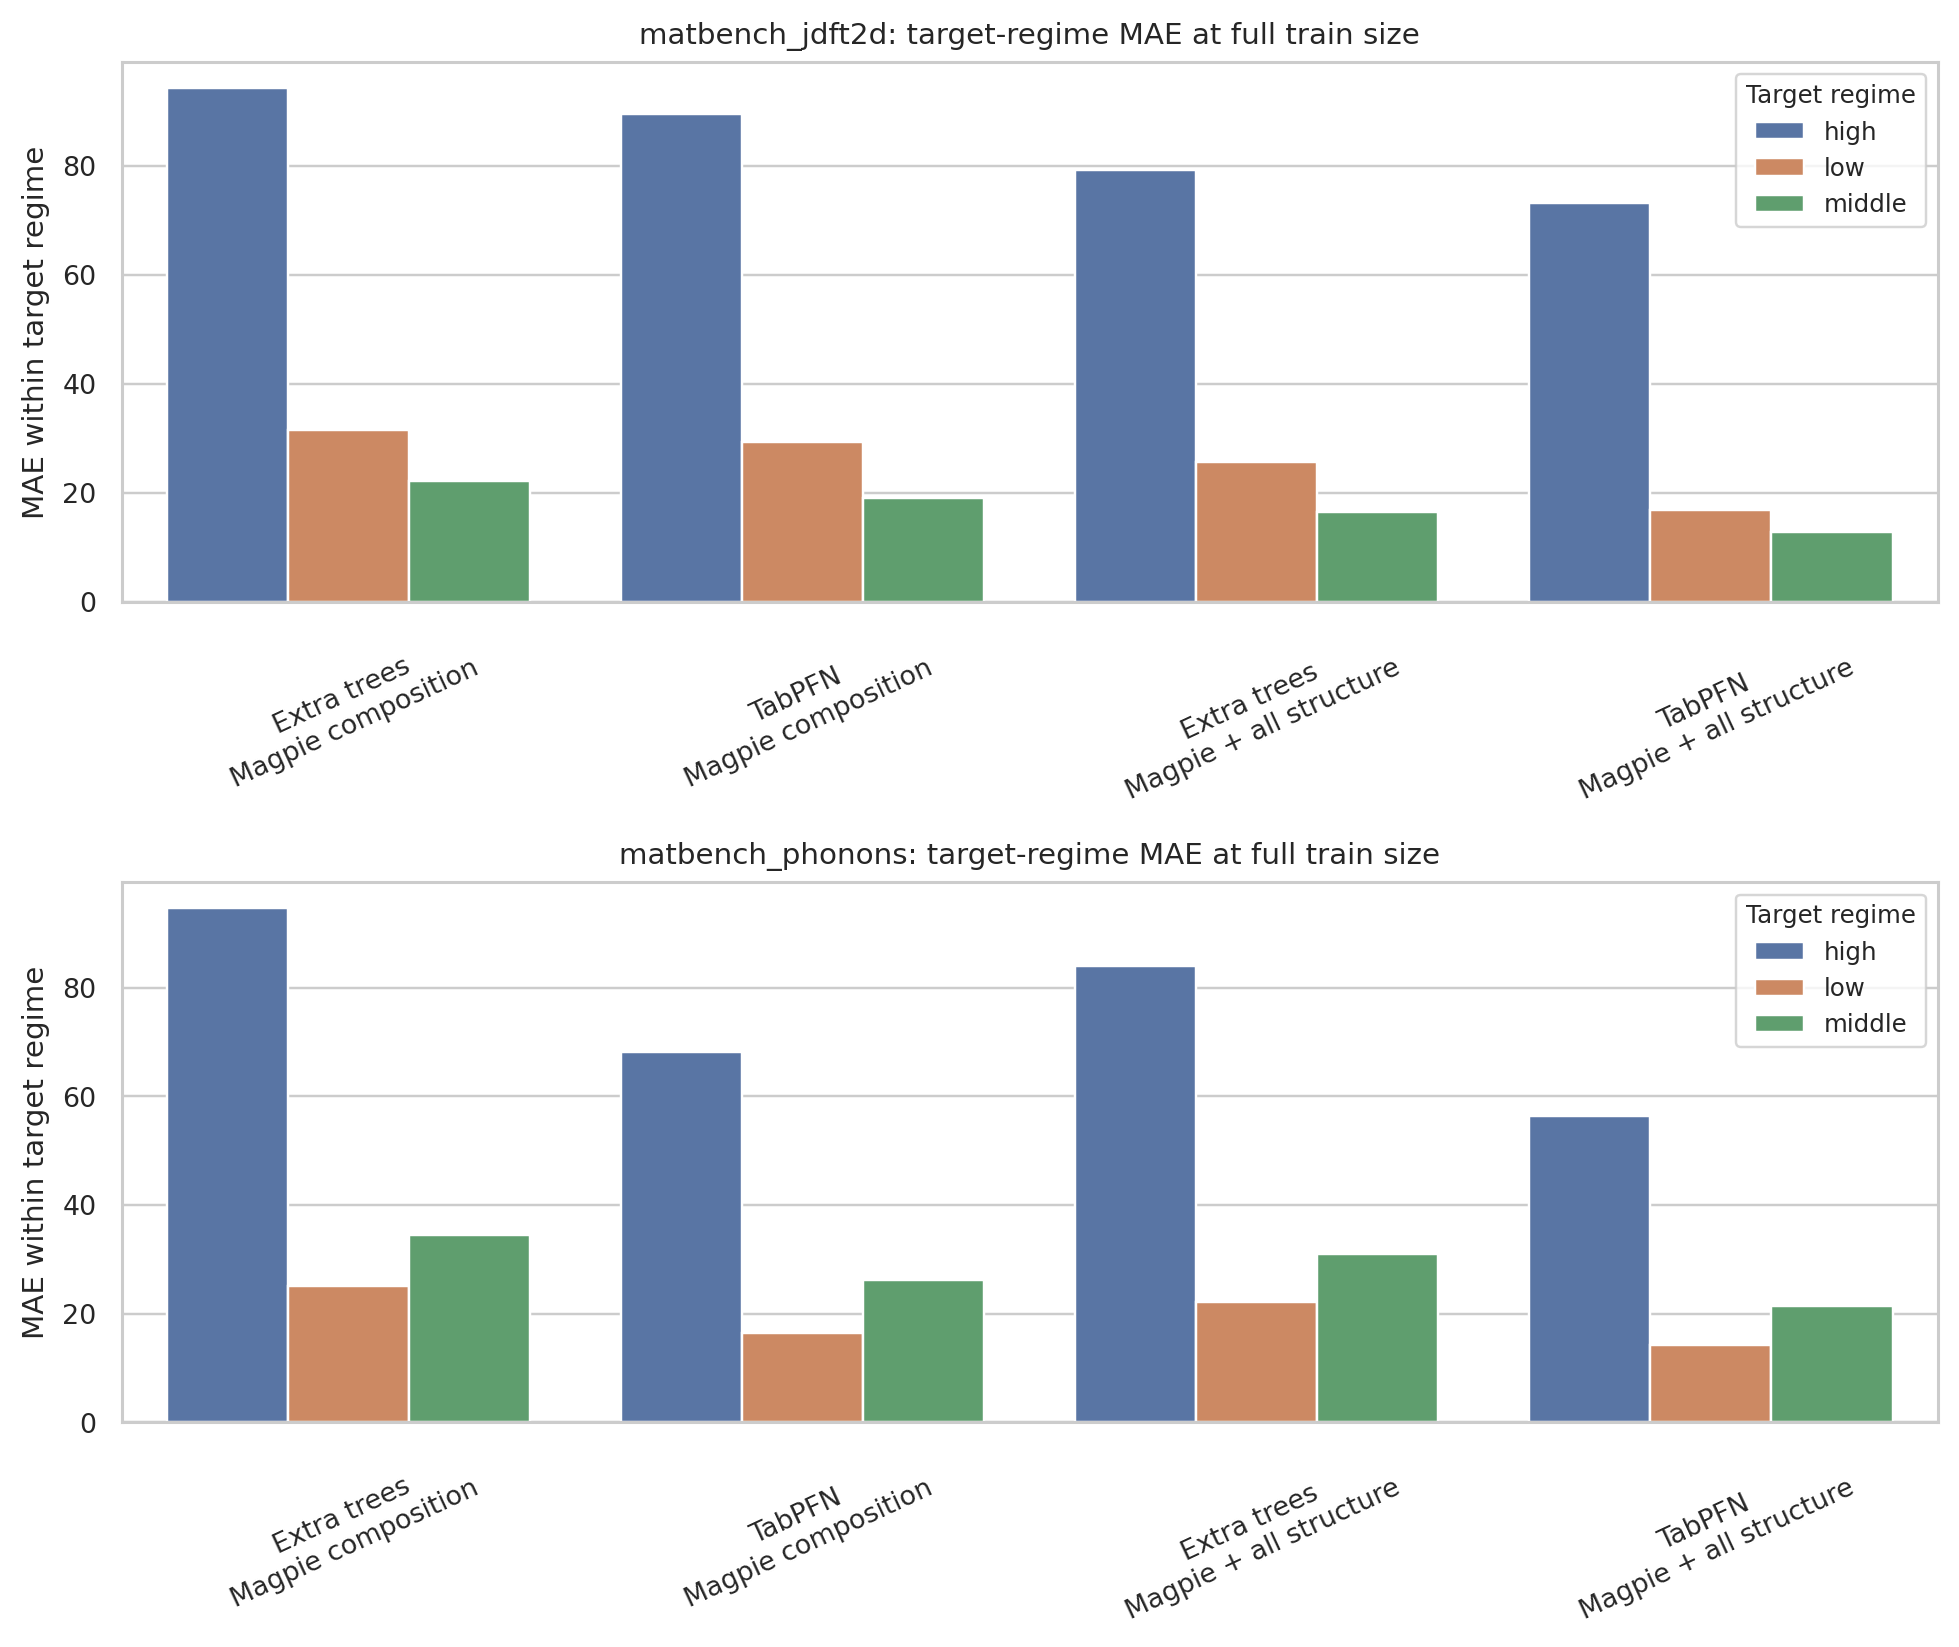

In [10]:
from IPython.display import Image, display

display(Image(f"{latest}/figures/small_data_learning_curve.png"))
display(Image(f"{latest}/figures/target_regime_error_diagnosis.png"))

In [11]:
!cat {latest}/tables/small_data_diagnostic_summary.md

# Small-Data Diagnostic Summary

This diagnostic asks whether the existing structure-aware TabPFN result is only a full-training-set benchmark result, or whether it remains useful when the official train folds are artificially reduced.

## Best Full-Train Results

- `matbench_jdft2d`: best full-train diagnostic model is TabPFN with Magpie + all structure, MAE=34.4.
- `matbench_phonons`: best full-train diagnostic model is TabPFN with Magpie + all structure, MAE=30.64.

## Representation Gain At Full Train Size

- `matbench_jdft2d` / `extra_trees`: all-structure improves over composition proxy by -17.99% MAE.
- `matbench_jdft2d` / `tabpfn`: all-structure improves over composition proxy by -25.43% MAE.
- `matbench_phonons` / `extra_trees`: all-structure improves over composition proxy by -11.07% MAE.
- `matbench_phonons` / `tabpfn`: all-structure improves over composition proxy by -16.84% MAE.

## Target-Regime Notes

- `matbench_jdft2d`: hardest full-train target regime in this diagnost

In [12]:
import pandas as pd

learning = pd.read_csv(f"{latest}/tables/small_data_learning_curve_summary.csv")
regime = pd.read_csv(f"{latest}/tables/target_regime_summary.csv")

learning.head(20), regime.head(20)

(               task           feature_set     feature_set_display  \
 0   matbench_jdft2d                magpie      Magpie composition   
 1   matbench_jdft2d                magpie      Magpie composition   
 2   matbench_jdft2d                magpie      Magpie composition   
 3   matbench_jdft2d                magpie      Magpie composition   
 4   matbench_jdft2d                magpie      Magpie composition   
 5   matbench_jdft2d                magpie      Magpie composition   
 6   matbench_jdft2d                magpie      Magpie composition   
 7   matbench_jdft2d                magpie      Magpie composition   
 8   matbench_jdft2d                magpie      Magpie composition   
 9   matbench_jdft2d                magpie      Magpie composition   
 10  matbench_jdft2d                magpie      Magpie composition   
 11  matbench_jdft2d                magpie      Magpie composition   
 12  matbench_jdft2d  magpie_structure_all  Magpie + all structure   
 13  matbench_jdft2d

In [13]:
!git pull

remote: Enumerating objects: 6, done.
remote: Counting objects: 100% (6/6), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 4 (delta 2), reused 4 (delta 2), pack-reused 0 (from 0)
Unpacking objects: 100% (4/4), 4.16 KiB | 4.16 MiB/s, done.
From https://github.com/ZuomingWang/matbench-tabpfn
   cfd0314..443f218  main       -> origin/main
Updating cfd0314..443f218
Fast-forward
 scripts/summarize_small_data_diagnostics.py | 389 ++++++++++++++++++++++++++++
 1 file changed, 389 insertions(+)
 create mode 100644 scripts/summarize_small_data_diagnostics.py


In [14]:
!ls scripts

check_setup.py		       setup_env.sh
run_small_data_diagnostics.py  summarize_small_data_diagnostics.py


In [15]:
!python scripts/summarize_small_data_diagnostics.py

/content/matbench-tabpfn/scripts/summarize_small_data_diagnostics.py:82: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  aulc = float(np.trapz(maes, fractions) / (fractions.max() - fractions.min()))
# Extended Small-Data Diagnostic Summary

## Data-Efficiency Ranking

- `matbench_jdft2d`: lowest AULC is TabPFN with Magpie + all structure, AULC=41.53.
- `matbench_phonons`: lowest AULC is TabPFN with Magpie + all structure, AULC=48.49.

## High-Target Regime

- `matbench_jdft2d` / Extra trees: all-structure reduces high-regime MAE by -15.91%.
- `matbench_jdft2d` / TabPFN: all-structure reduces high-regime MAE by -18.25%.
- `matbench_phonons` / Extra trees: all-structure reduces high-regime MAE by -11.21%.
- `matbench_phonons` / TabPFN: all-structure reduces high-regime MAE by -17.11%.

## Disagreement As Error Proxy

- `matbench_jdft2d` / Magpie composition: Spearman(disagreement, TabPFN error)=0.53

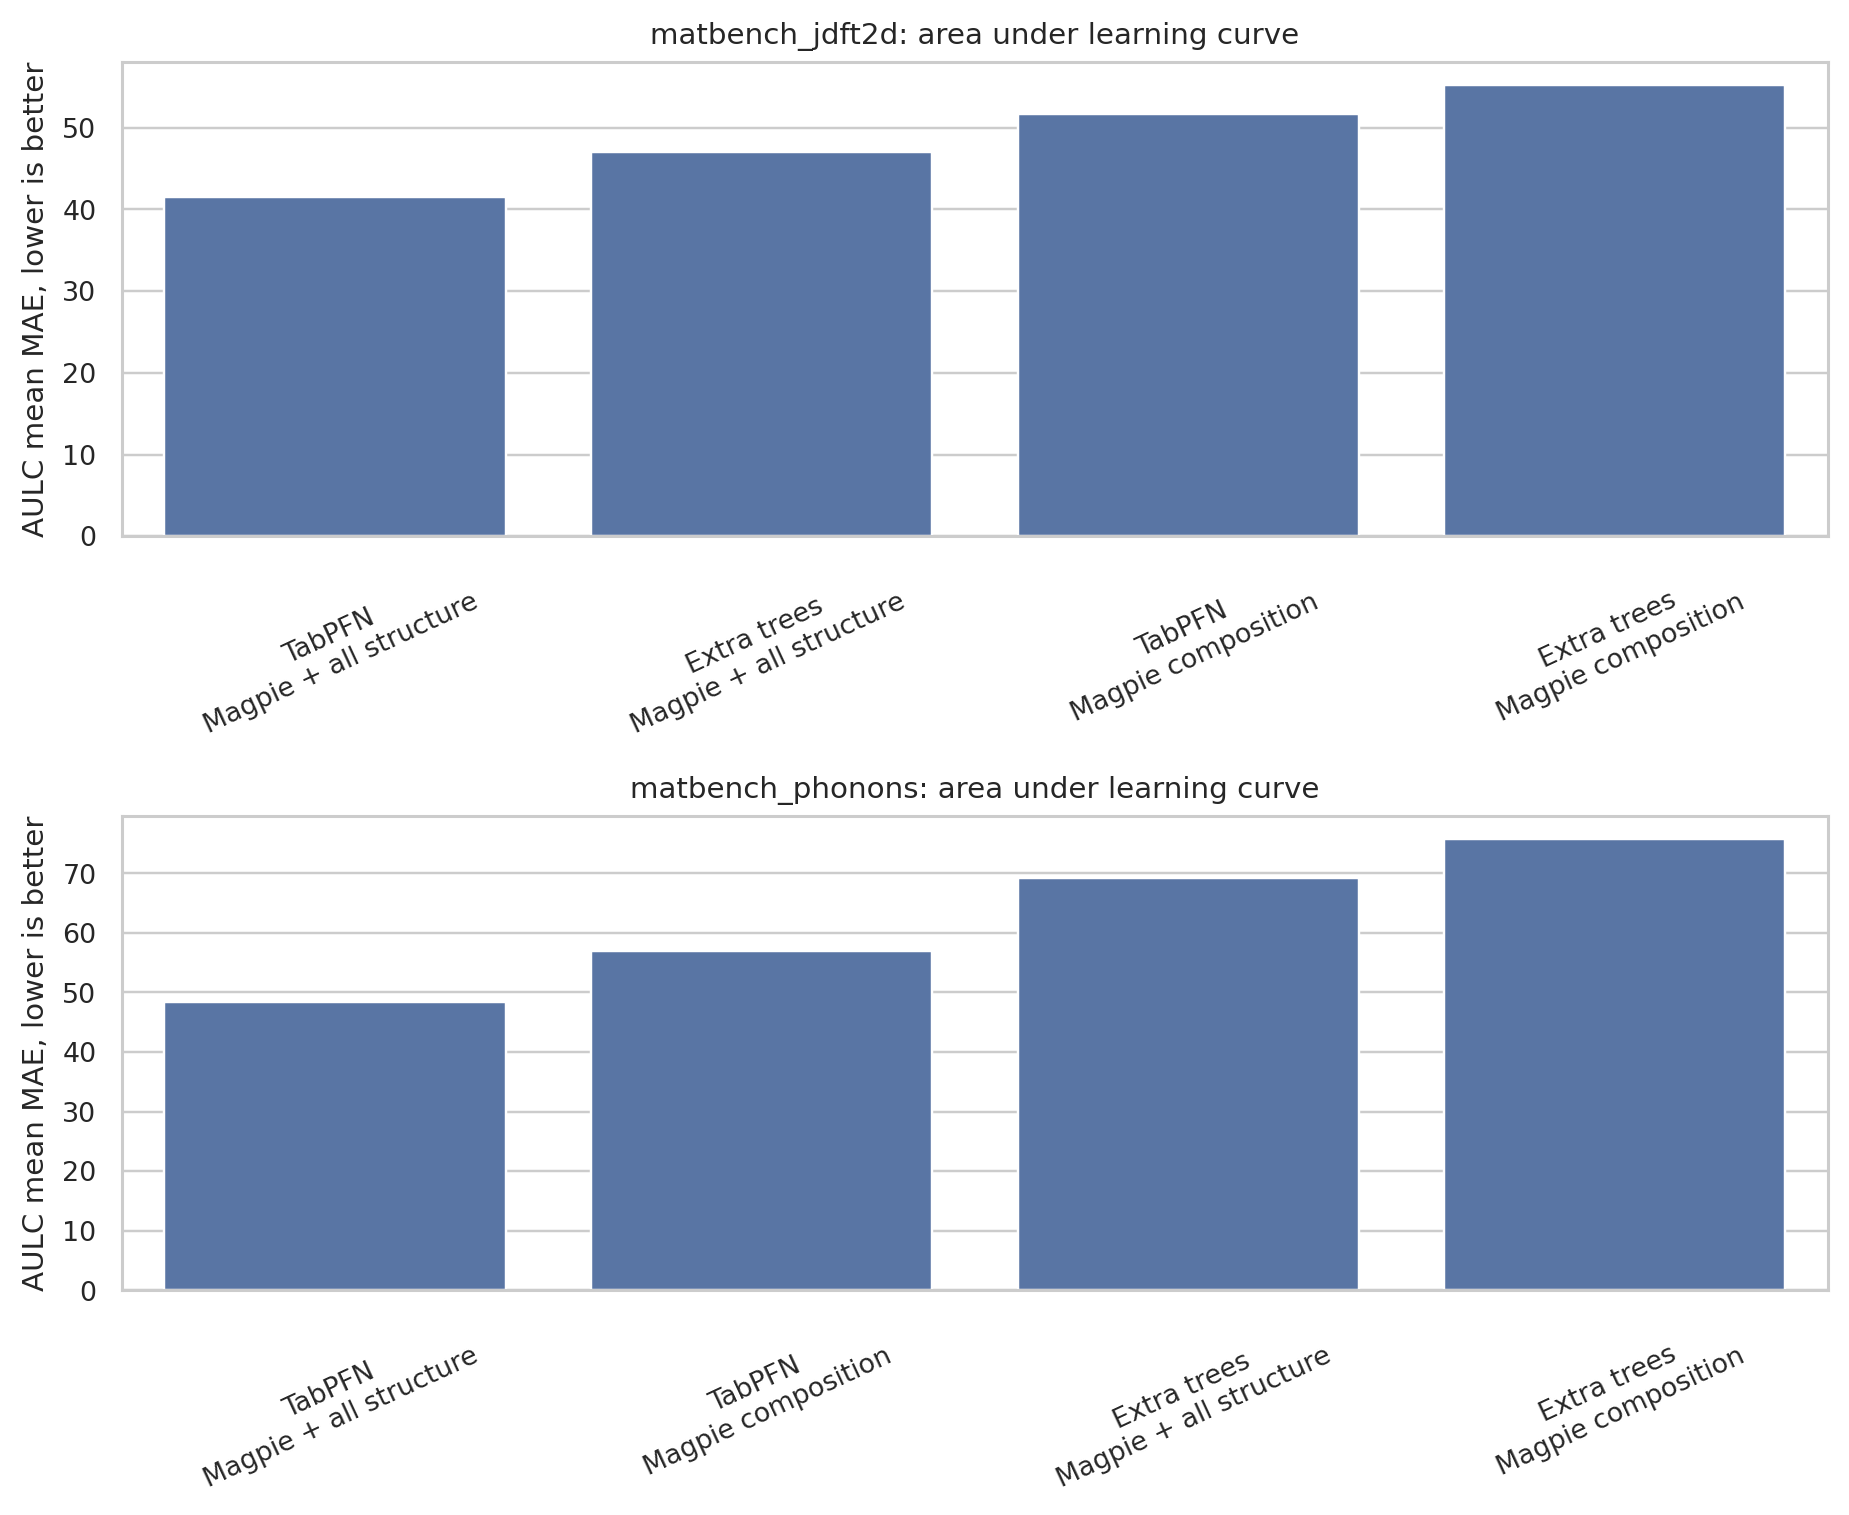

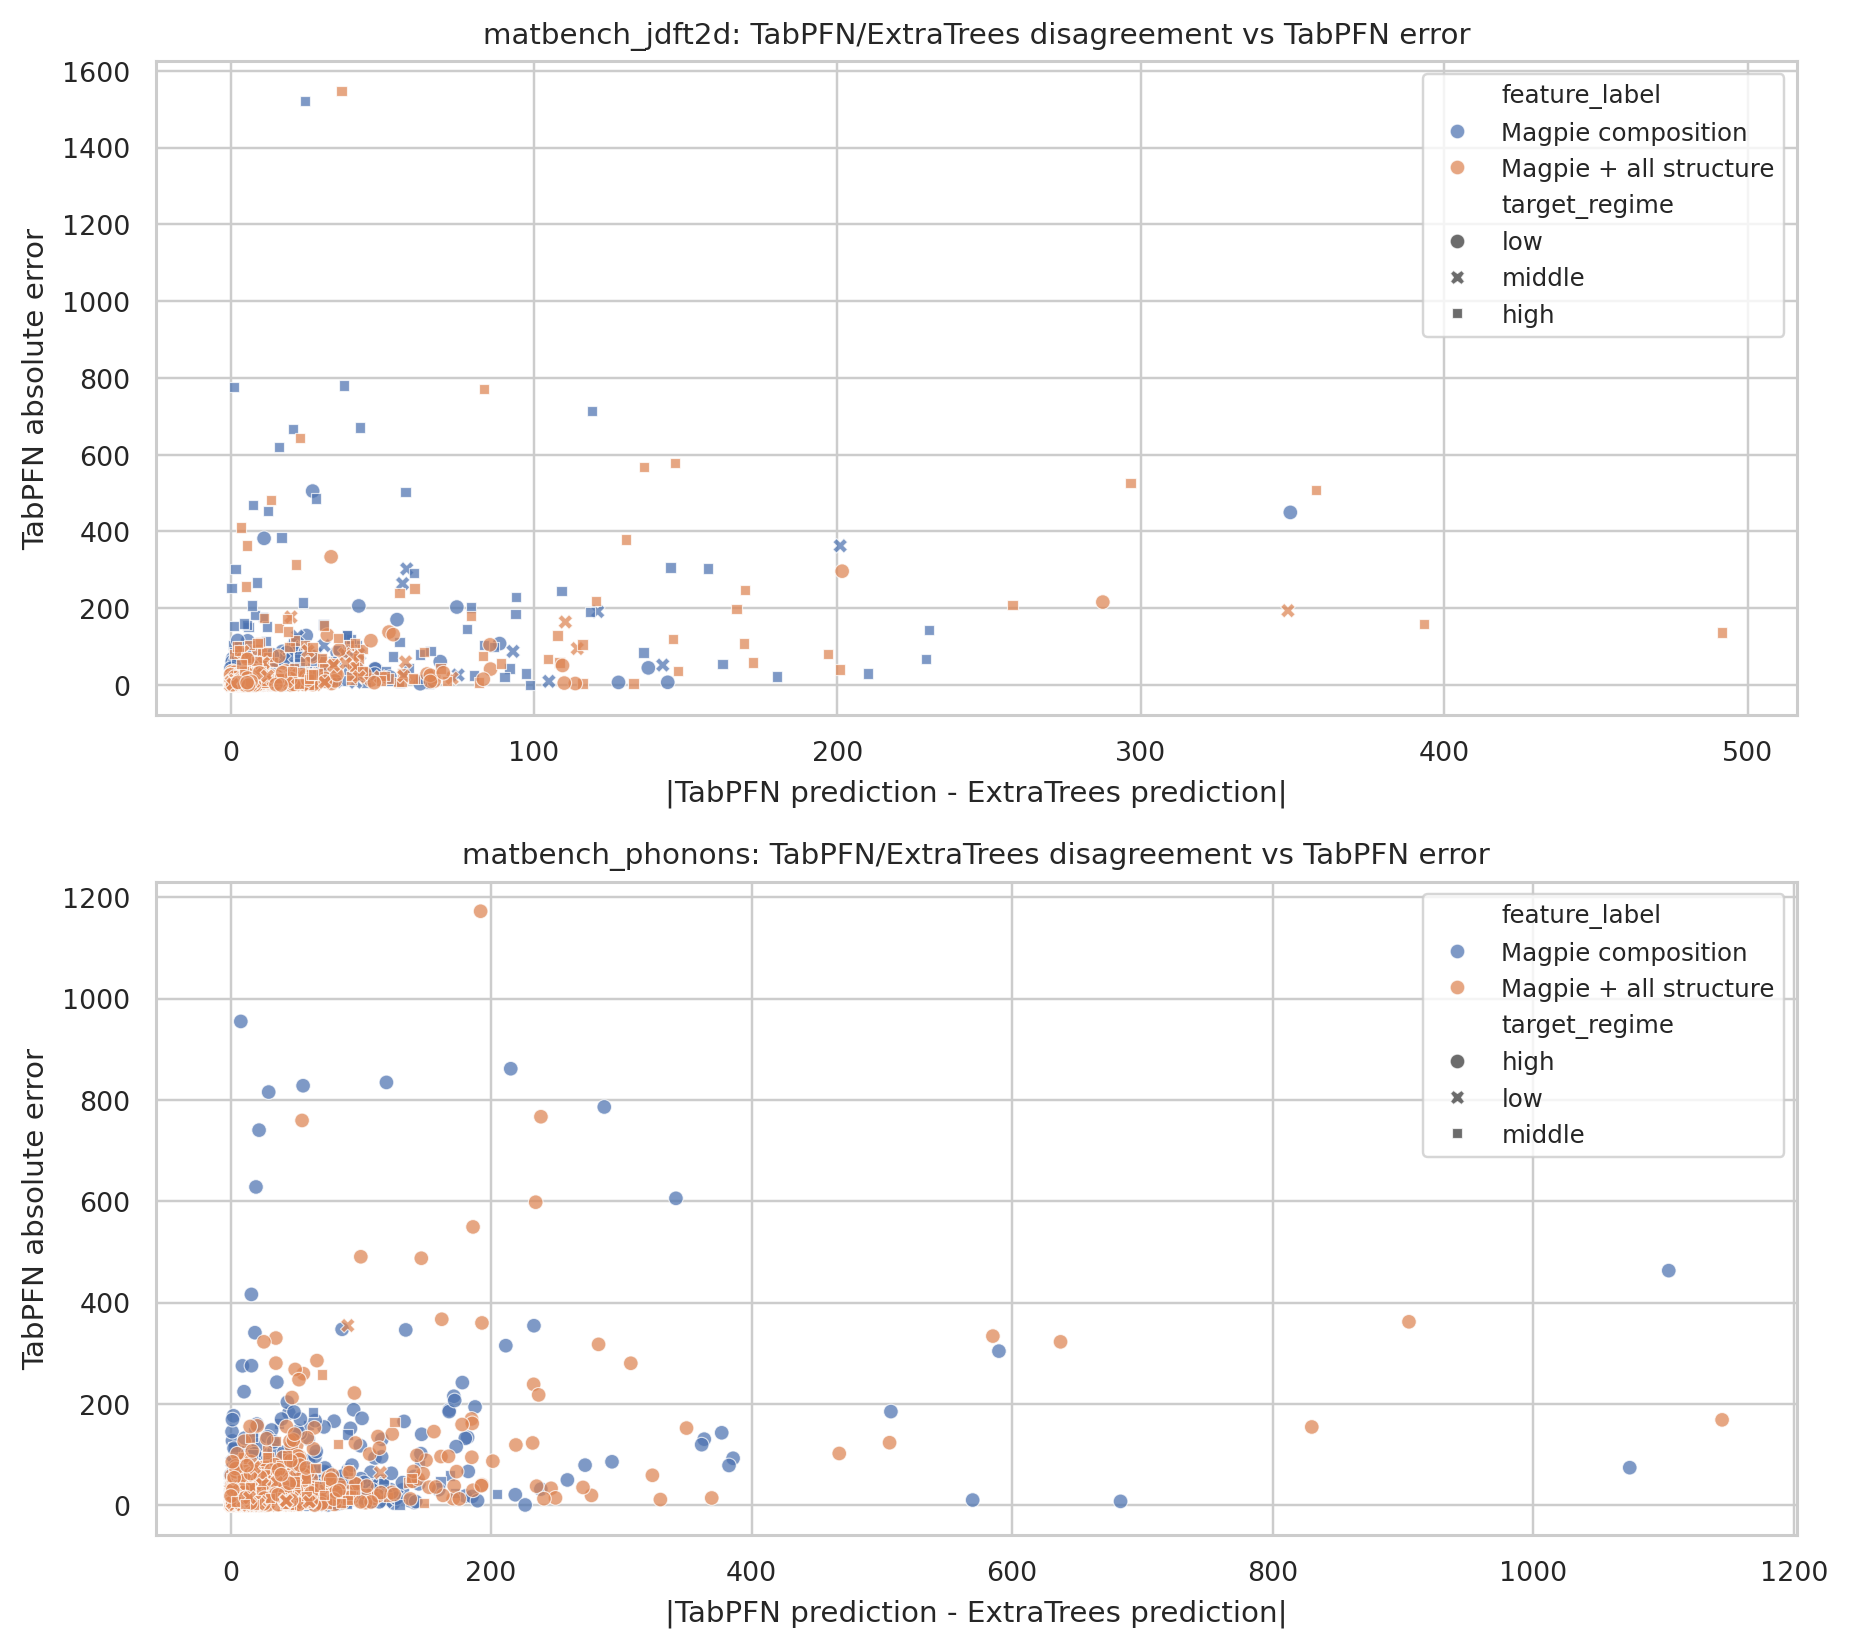

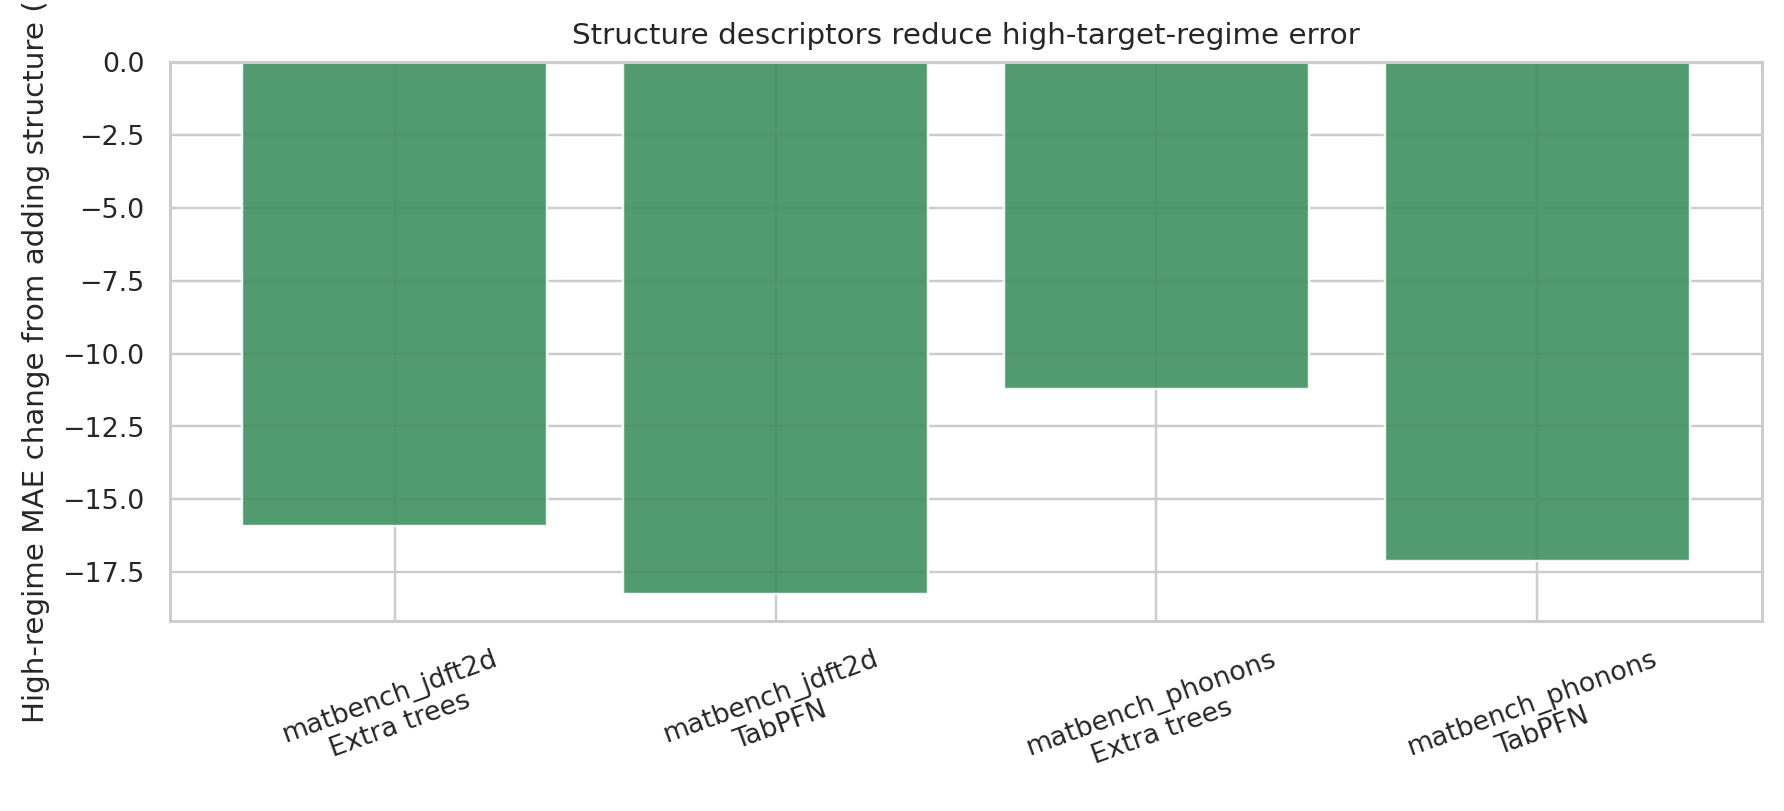

In [16]:
from IPython.display import Image, display
import glob

latest = sorted(glob.glob("results/small_data_diagnostics/*"))[-1]

display(Image(f"{latest}/figures/aulc_data_efficiency_ranking.png"))
display(Image(f"{latest}/figures/model_disagreement_error_proxy.png"))
display(Image(f"{latest}/figures/high_target_structure_improvement.png"))

In [17]:
!cat {latest}/tables/extended_small_data_diagnostic_summary.md

# Extended Small-Data Diagnostic Summary

## Data-Efficiency Ranking

- `matbench_jdft2d`: lowest AULC is TabPFN with Magpie + all structure, AULC=41.53.
- `matbench_phonons`: lowest AULC is TabPFN with Magpie + all structure, AULC=48.49.

## High-Target Regime

- `matbench_jdft2d` / Extra trees: all-structure reduces high-regime MAE by -15.91%.
- `matbench_jdft2d` / TabPFN: all-structure reduces high-regime MAE by -18.25%.
- `matbench_phonons` / Extra trees: all-structure reduces high-regime MAE by -11.21%.
- `matbench_phonons` / TabPFN: all-structure reduces high-regime MAE by -17.11%.

## Disagreement As Error Proxy

- `matbench_jdft2d` / Magpie composition: Spearman(disagreement, TabPFN error)=0.538; high-disagreement TabPFN MAE is 107.5 vs 25.67 for lower-disagreement samples.
- `matbench_jdft2d` / Magpie + all structure: Spearman(disagreement, TabPFN error)=0.549; high-disagreement TabPFN MAE is 93.16 vs 14.8 for lower-disagreement samples.
- `matbench_phonons` / Magpie compositi